# Homework 4 — Task 3: Word Embeddings

- **Part 1:** Loading and using pre-trained word embeddings (GloVe via Gensim)
- **Part 2:** Cosine similarity computation with visualization (PCA / t-SNE)
- **Part 3:** Custom dissimilarity metric with comparison heatmaps

## Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine as cosine_dist
import warnings
warnings.filterwarnings('ignore')
!pip install gensim
import gensim.downloader as api

print('All imports successful!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.1 MB/s eta 0:00:00
All imports successful!


---
## Part 1: Implementing Word Embeddings

### Embedding Choice: GloVe (glove-wiki-gigaword-100)

**Why GloVe over alternatives?**

| Model | Approach | Pros | Cons |
|-------|----------|------|------|
| **GloVe** | Global co-occurrence matrix factorization | Fast inference, captures global semantics, fixed 50–300d vectors | Static (one vector per word), no context sensitivity |
| Word2Vec | Local context window (CBOW/Skip-gram) | Simple, fast to train | Local context only, no sub-word info |
| FastText | Sub-word n-grams | Handles OOV via sub-words natively | Larger model, slower |
| BERT | Transformer, contextual | Best for downstream NLP tasks | Very large, slow for similarity, context-dependent |

**We chose GloVe** because:
1. Efficient for similarity tasks — vectors are fixed and fast to compare
2. Captures global semantic relationships well (trained on 6B token Wikipedia corpus)
3. Widely used as a baseline — well understood and reproducible
4. BERT would be overkill for static word similarity; FastText's OOV advantage isn't needed here

In [3]:
#Load GloVe embeddings
print('Loading GloVe embeddings (100d)...')
glove = api.load('glove-wiki-gigaword-100')
print(f'Loaded! Vocabulary size: {len(glove.key_to_index):,} words')
print(f'Vector dimensions: {glove.vector_size}')

Loading GloVe embeddings (100d)... This may take a minute on first run.
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded! Vocabulary size: 400,000 words
Vector dimensions: 100


In [4]:
def get_embedding(word, model=glove):
    word_lower = word.lower()
    if word_lower in model.key_to_index:
        return model[word_lower], True
    #Strategy 1: Try removing trailing 's' (basic stemming)
    stemmed = word_lower.rstrip('s')
    if len(stemmed) > 2 and stemmed in model.key_to_index:
        print(f"OOV: '{word}' not found. Using stemmed form '{stemmed}'.")
        return model[stemmed], True
    #Strategy 2: Suggest similar vocabulary words
    try:
        similar = model.most_similar(positive=[], negative=[], topn=3)
        suggestions = [w for w, _ in model.similar_by_word(word_lower, topn=3)]
    except Exception:
        suggestions = []
    print(f"OOV: '{word}' not in vocabulary.")
    if suggestions:
        print(f"  Nearest vocabulary words: {suggestions}")
        print(f"  Approximating with average of nearest neighbors.")
        vecs = [model[s] for s in suggestions if s in model.key_to_index]
        if vecs:
            return np.mean(vecs, axis=0), False
    #Strategy 3: Zero vector
    print(f"  Returning zero vector for '{word}'.")
    return np.zeros(model.vector_size), False
#Demo: get embeddings for two user-specified words
word1, word2 = 'king', 'queen'
vec1, found1 = get_embedding(word1)
vec2, found2 = get_embedding(word2)
print(f"\nEmbedding for '{word1}' (found={found1}): shape={vec1.shape}, first 5 values={vec1[:5].round(4)}")
print(f"Embedding for '{word2}' (found={found2}): shape={vec2.shape}, first 5 values={vec2[:5].round(4)}")
#Classic king - man + woman ≈ queen demonstration
print('\n=== Classic analogy test: king - man + woman ≈ ? ===')
result = glove.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
for word, score in result:
    print(f'  {word}: {score:.4f}')


Embedding for 'king' (found=True): shape=(100,), first 5 values=[-0.3231 -0.8762  0.2198  0.2527  0.2298]
Embedding for 'queen' (found=True): shape=(100,), first 5 values=[-0.5004 -0.7083  0.5539  0.673   0.2249]

=== Classic analogy test: king - man + woman ≈ ? ===
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [5]:
#Demonstrate OOV handling
print('=== OOV Handling Demo ===')
oov_word = 'Zyphronix'#Made-up word
vec_oov, found_oov = get_embedding(oov_word)
print(f'  Vector is zero: {np.allclose(vec_oov, 0)}')

=== OOV Handling Demo ===
OOV: 'Zyphronix' not in vocabulary.
  Returning zero vector for 'Zyphronix'.
  Vector is zero: True


---
## Part 2: Cosine Similarity Computation

### Why Cosine Similarity?

Cosine similarity measures the **angle** between two vectors rather than their absolute distance:

$$\text{cosine}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\| \|\mathbf{v}\|}$$

In word embedding space, this is preferable to Euclidean distance because:
1. Word vectors vary in magnitude (frequency-related scaling), so direction carries more semantic meaning than magnitude
2. Scale-invariant: 'dog' and 'puppy' should be similar regardless of how often each word appears
3. Range is [-1, 1] → easy to interpret: 1 = identical direction, 0 = orthogonal, -1 = opposite

In [6]:
def cosine_similarity(vec1, vec2):
    """Compute cosine similarity between two vectors."""
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return np.dot(vec1, vec2) / (norm1 * norm2)

def batch_cosine_similarity(word_pairs, model=glove):
    results = []
    for w1, w2 in word_pairs:
        v1, _ = get_embedding(w1, model)
        v2, _ = get_embedding(w2, model)
        sim = cosine_similarity(v1, v2)
        results.append({'Word 1': w1, 'Word 2': w2, 'Cosine Similarity': round(sim, 4)})
    return pd.DataFrame(results)
# Batch similarity computation
word_pairs = [
    ('cat', 'dog'),
    ('cat', 'lion'),
    ('cat', 'table'),
    ('king', 'queen'),
    ('king', 'man'),
    ('happy', 'joyful'),
    ('happy', 'sad'),
    ('computer', 'laptop'),
    ('computer', 'banana'),
    ('paris', 'france'),
    ('paris', 'berlin'),
    ('love', 'hate'),
]
sim_df = batch_cosine_similarity(word_pairs)
print(sim_df.sort_values('Cosine Similarity', ascending=False).to_string(index=False))

  Word 1 Word 2  Cosine Similarity
     cat    dog             0.8798
    king  queen             0.7508
   paris france             0.7482
computer laptop             0.7024
   happy    sad             0.6801
   paris berlin             0.6586
     cat   lion             0.5956
    love   hate             0.5704
   happy joyful             0.5260
    king    man             0.5119
     cat  table             0.3101
computer banana             0.1213


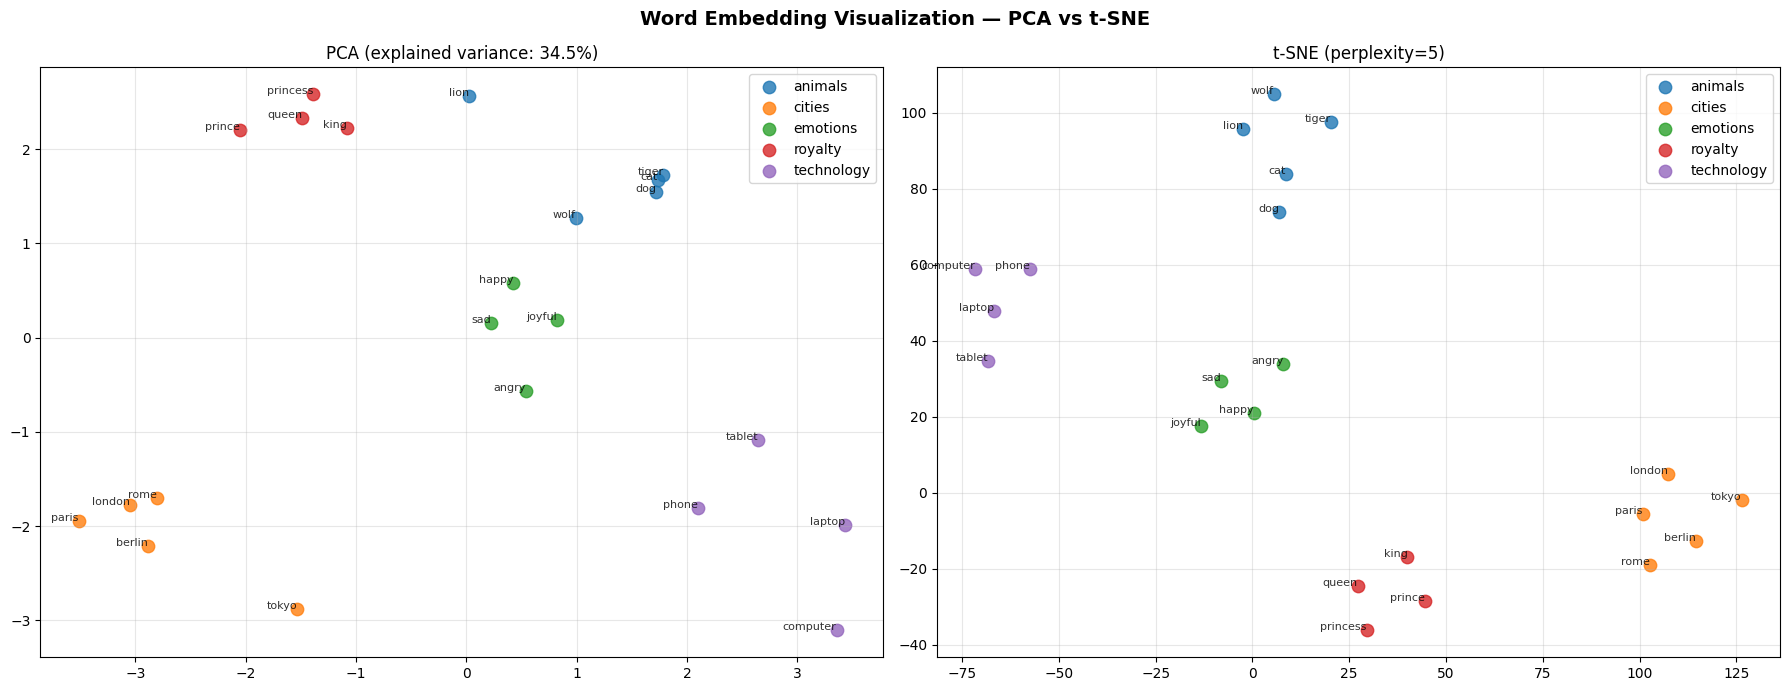

Observation: Both PCA and t-SNE show words clustering by semantic category.


In [7]:
#2D visualization with PCA and t-SNE
words_to_plot = [
    'cat', 'dog', 'lion', 'tiger', 'wolf',       # animals
    'king', 'queen', 'prince', 'princess',         # royalty
    'computer', 'laptop', 'phone', 'tablet',       # technology
    'paris', 'london', 'berlin', 'rome', 'tokyo',  # cities
    'happy', 'sad', 'joyful', 'angry',             # emotions
]
categories = (
    ['animals'] * 5 + ['royalty'] * 4 + ['technology'] * 4 +
    ['cities'] * 5 + ['emotions'] * 4
)
vectors = np.array([glove[w] for w in words_to_plot if w in glove.key_to_index])
valid_words = [w for w in words_to_plot if w in glove.key_to_index]
valid_cats  = [c for w, c in zip(words_to_plot, categories) if w in glove.key_to_index]
#Color mapping
cat_list    = sorted(set(valid_cats))
palette     = sns.color_palette('tab10', len(cat_list))
cat_to_color = {c: palette[i] for i, c in enumerate(cat_list)}
colors      = [cat_to_color[c] for c in valid_cats]
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Word Embedding Visualization — PCA vs t-SNE', fontsize=14, fontweight='bold')
#PCA
pca  = PCA(n_components=2)
pca_result = pca.fit_transform(vectors)
for cat in cat_list:
    mask = [c == cat for c in valid_cats]
    axes[0].scatter(pca_result[mask, 0], pca_result[mask, 1],
                    c=[cat_to_color[cat]], label=cat, s=80, alpha=0.8)
for i, word in enumerate(valid_words):
    axes[0].annotate(word, (pca_result[i, 0], pca_result[i, 1]),
                     fontsize=8, ha='right', alpha=0.8)
axes[0].set_title(f'PCA (explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)')
axes[0].legend()
axes[0].grid(alpha=0.3)
#t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000)
tsne_result = tsne.fit_transform(vectors)
for cat in cat_list:
    mask = [c == cat for c in valid_cats]
    axes[1].scatter(tsne_result[mask, 0], tsne_result[mask, 1],
                    c=[cat_to_color[cat]], label=cat, s=80, alpha=0.8)
for i, word in enumerate(valid_words):
    axes[1].annotate(word, (tsne_result[i, 0], tsne_result[i, 1]),
                     fontsize=8, ha='right', alpha=0.8)
axes[1].set_title('t-SNE (perplexity=5)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('Observation: Both PCA and t-SNE show words clustering by semantic category.')

---
## Part 3: Novel Dissimilarity Metric

### Our Custom Metric: Weighted Composite Dissimilarity (WCD)

We define a **Weighted Composite Dissimilarity (WCD)** score that combines three components:

$$\text{WCD}(\mathbf{u}, \mathbf{v}) = \alpha \cdot d_{\cos} + \beta \cdot d_{\text{norm}} + \gamma \cdot d_{\text{angle}}$$

Where:
- $d_{\cos} = 1 - \text{cosine\_similarity}(\mathbf{u}, \mathbf{v})$ — direction difference
- $d_{\text{norm}} = \frac{\|\mathbf{u} - \mathbf{v}\|_2}{\sqrt{n}}$ — normalized Euclidean distance (magnitude difference)
- $d_{\text{angle}} = \frac{\arccos(\text{clamp}(\cos, -1, 1))}{\pi}$ — angular distance normalized to [0,1]
- Default weights: $\alpha=0.4, \beta=0.3, \gamma=0.3$

**Why this goes beyond cosine similarity:**  
Cosine similarity ignores vector magnitude — two words could have very similar directions but very different magnitudes (which may encode frequency/importance). The Euclidean term captures this magnitude difference. The angular term provides a geometrically pure directional measure. Their combination gives a more holistic view of semantic distance.

**Reference:** Inspired by the framework of Mikolov et al. (2013) and the multi-metric approach described in Schnabel et al. (2015), *"Evaluation methods for unsupervised word embeddings"*, EMNLP.

In [9]:
def cosine_dissimilarity(u, v):
    """1 - cosine_similarity. Range [0, 2]."""
    return 1 - cosine_similarity(u, v)

def euclidean_dissimilarity(u, v):
    """L2 distance normalized by sqrt(dims)."""
    return np.linalg.norm(u - v) / np.sqrt(len(u))

def angular_dissimilarity(u, v):
    """Angle between vectors normalized to [0, 1]."""
    cos_sim = cosine_similarity(u, v)
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    angle   = np.arccos(cos_sim)#in radians [0, pi]
    return angle / np.pi#normalize to [0, 1]

def wcd(u, v, alpha=0.4, beta=0.3, gamma=0.3, metric='wcd'):
    """
    Weighted Composite Dissimilarity.

    Args:
        u, v   : word vectors
        alpha  : weight for cosine dissimilarity
        beta   : weight for Euclidean distance
        gamma  : weight for angular distance
        metric : 'wcd', 'cosine', 'euclidean', or 'angular'
    """
    if metric == 'cosine':
        return cosine_dissimilarity(u, v)
    elif metric == 'euclidean':
        return euclidean_dissimilarity(u, v)
    elif metric == 'angular':
        return angular_dissimilarity(u, v)
    else:#wcd
        d_cos  = cosine_dissimilarity(u, v)
        d_norm = euclidean_dissimilarity(u, v)
        d_ang  = angular_dissimilarity(u, v)
        return alpha * d_cos + beta * d_norm + gamma * d_ang

def word_dissimilarity(word1, word2, model=glove, metric='wcd', **kwargs):
    """High-level function: get dissimilarity between two words by name."""
    v1, _ = get_embedding(word1, model)
    v2, _ = get_embedding(word2, model)
    return wcd(v1, v2, metric=metric, **kwargs)

#Demo: compare metrics on sample pairs
test_pairs = [('cat', 'dog'), ('cat', 'table'), ('king', 'queen'), ('happy', 'sad')]
metrics_to_test = ['cosine', 'euclidean', 'angular', 'wcd']
print('Dissimilarity scores (lower = more similar):')
print(f'{"Pair":<20}', '  '.join(f'{m:>12}' for m in metrics_to_test))
print('-' * 72)
for w1, w2 in test_pairs:
    scores = [word_dissimilarity(w1, w2, metric=m) for m in metrics_to_test]
    pair_str = f'{w1} vs {w2}'
    print(f'{pair_str:<20}', '  '.join(f'{s:>12.4f}' for s in scores))

Dissimilarity scores (lower = more similar):
Pair                       cosine     euclidean       angular           wcd
------------------------------------------------------------------------
cat vs dog                 0.1202        0.2681        0.1577        0.1758
cat vs table               0.6899        0.6161        0.3996        0.5807
king vs queen              0.2492        0.4281        0.2297        0.2970
happy vs sad               0.3199        0.4428        0.2619        0.3394


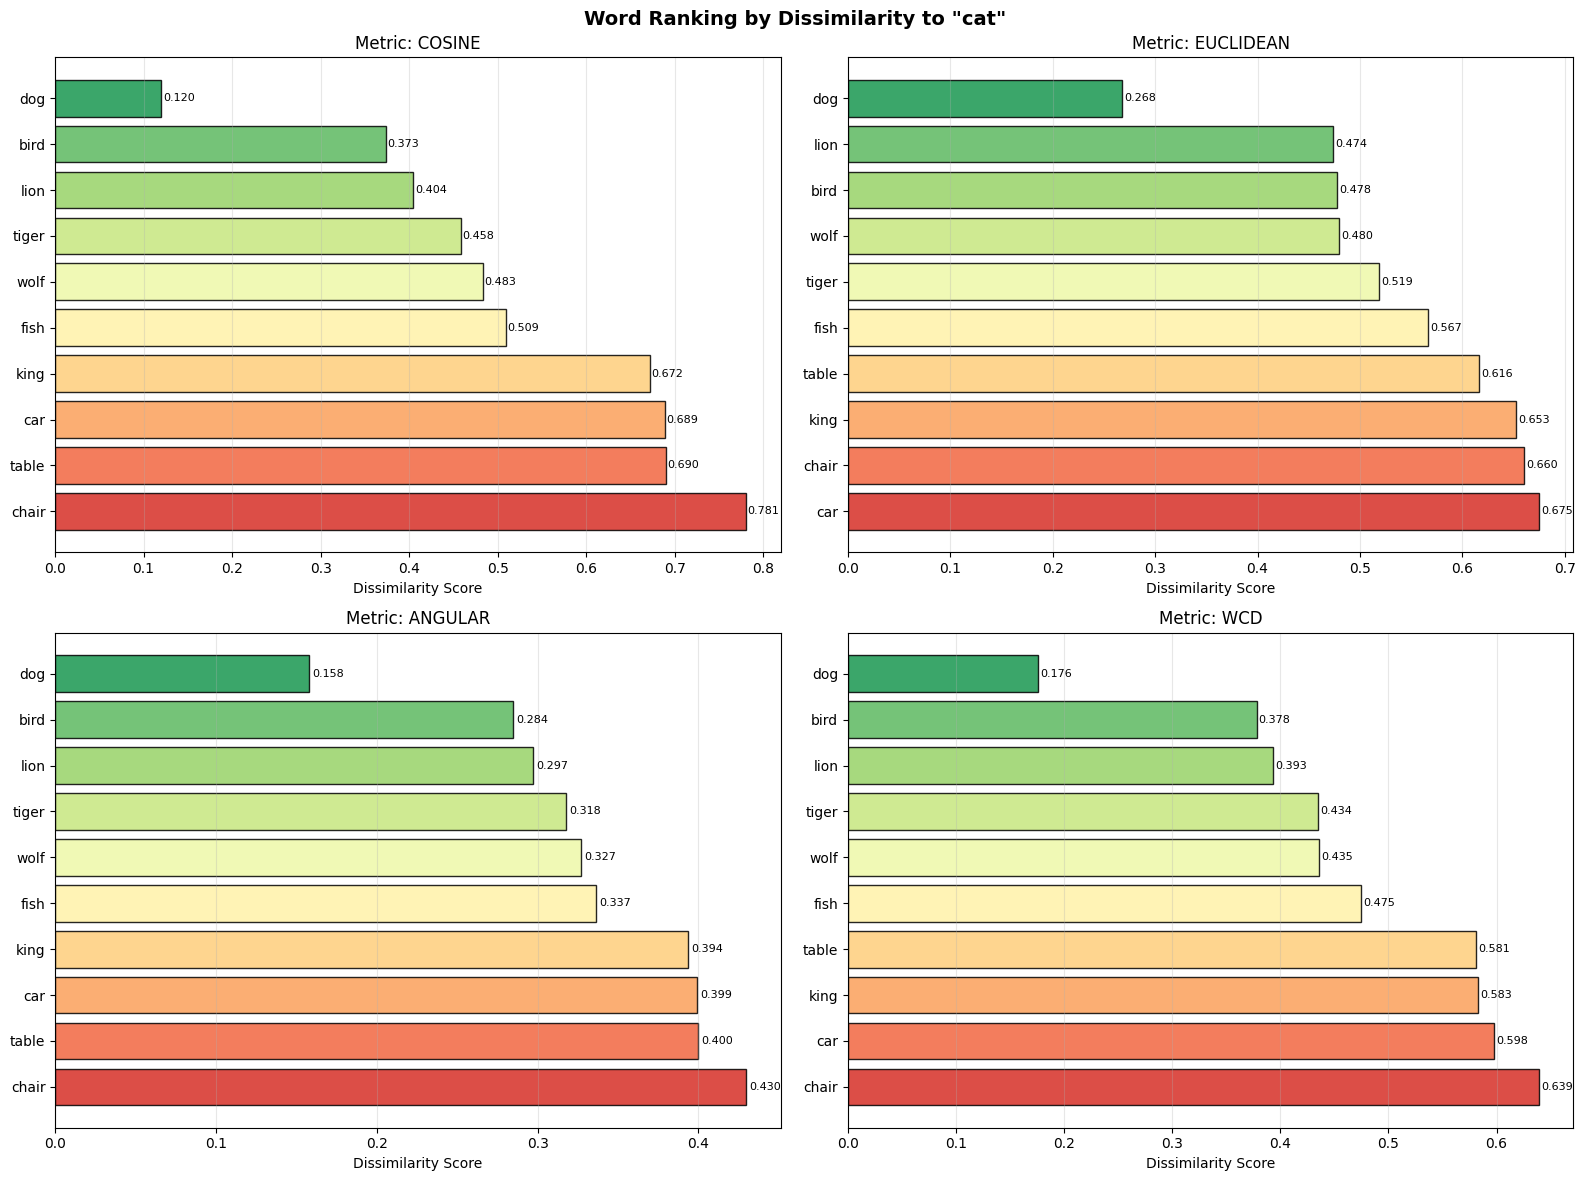

In [10]:
#Visualization 1: Word ranking by dissimilarity to a query word
query_word = 'cat'
comparison_words = ['dog', 'lion', 'tiger', 'wolf', 'table', 'chair', 'king', 'fish', 'bird', 'car']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Word Ranking by Dissimilarity to "{query_word}"', fontsize=14, fontweight='bold')
q_vec, _ = get_embedding(query_word)
for ax, metric in zip(axes.flatten(), metrics_to_test):
    scores = []
    for w in comparison_words:
        v, _ = get_embedding(w)
        scores.append(wcd(q_vec, v, metric=metric))
    sorted_pairs = sorted(zip(comparison_words, scores), key=lambda x: x[1])
    words_sorted  = [p[0] for p in sorted_pairs]
    scores_sorted = [p[1] for p in sorted_pairs]
    colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(words_sorted)))
    bars = ax.barh(words_sorted, scores_sorted, color=colors_bar, edgecolor='black', alpha=0.85)
    ax.set_title(f'Metric: {metric.upper()}')
    ax.set_xlabel('Dissimilarity Score')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')
    for bar, score in zip(bars, scores_sorted):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

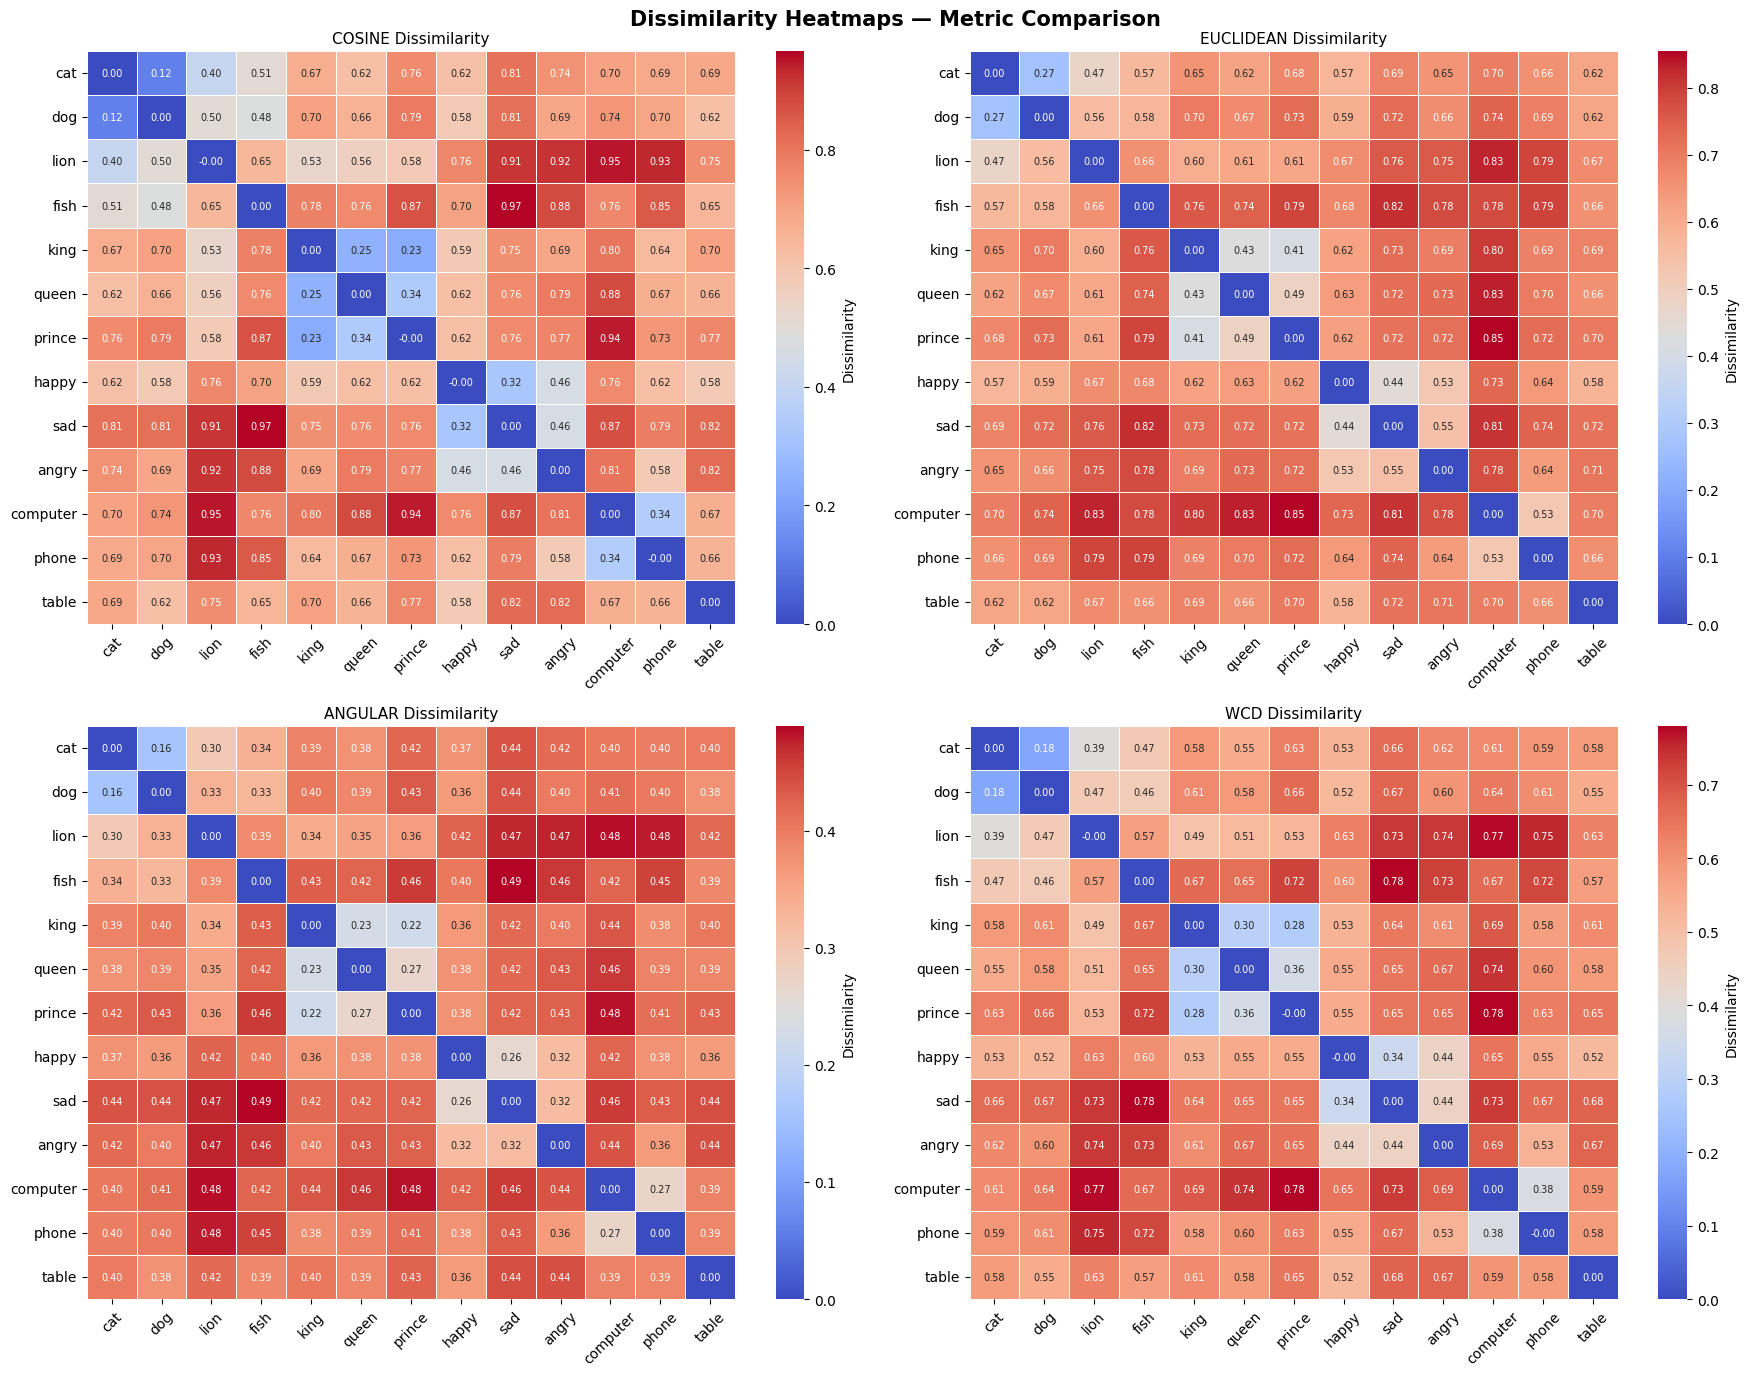

In [11]:
#Visualization 2: Heatmap comparing similarity/dissimilarity across word pairs
heatmap_words = [
    'cat', 'dog', 'lion', 'fish',
    'king', 'queen', 'prince',
    'happy', 'sad', 'angry',
    'computer', 'phone', 'table'
]
def build_matrix(words, model=glove, metric='wcd'):
    n = len(words)
    mat = np.zeros((n, n))
    vecs = [get_embedding(w, model)[0] for w in words]
    for i in range(n):
        for j in range(n):
            mat[i, j] = wcd(vecs[i], vecs[j], metric=metric)
    return mat
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Dissimilarity Heatmaps — Metric Comparison', fontsize=15, fontweight='bold')
for ax, metric in zip(axes.flatten(), metrics_to_test):
    mat = build_matrix(heatmap_words, metric=metric)
    im  = sns.heatmap(mat, ax=ax, xticklabels=heatmap_words, yticklabels=heatmap_words,
                      cmap='coolwarm', annot=True, fmt='.2f',
                      annot_kws={'size': 7}, linewidths=0.5,
                      vmin=0, cbar_kws={'label': 'Dissimilarity'})
    ax.set_title(f'{metric.upper()} Dissimilarity', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

In [12]:
#Show how WCD differs from pure cosine on semantic categories
print('=== WCD vs Cosine: Key Differences ===')
interesting_pairs = [
    ('frequent', 'common'),   # high-frequency near-synonyms
    ('fast', 'quick'),
    ('large', 'big'),
    ('cat', 'kitten'),
]
print(f'{"Pair":<20}  {"Cosine Dissim":>16}  {"WCD":>10}  {"Difference":>12}')
print('-' * 65)
for w1, w2 in interesting_pairs:
    if w1 in glove.key_to_index and w2 in glove.key_to_index:
        c_score = word_dissimilarity(w1, w2, metric='cosine')
        w_score = word_dissimilarity(w1, w2, metric='wcd')
        print(f'{w1+" vs "+w2:<20}  {c_score:>16.4f}  {w_score:>10.4f}  {w_score-c_score:>12.4f}')
print('\nConclusion: WCD captures both directional AND magnitude differences.')
print('When two near-synonyms have different vector magnitudes (frequency-related),')
print('WCD penalizes this more than pure cosine dissimilarity.')

=== WCD vs Cosine: Key Differences ===
Pair                     Cosine Dissim         WCD    Difference
-----------------------------------------------------------------
frequent vs common              0.5008      0.4598       -0.0410
fast vs quick                   0.2893      0.3101        0.0208
large vs big                    0.2918      0.3226        0.0308
cat vs kitten                   0.4419      0.4039       -0.0381

Conclusion: WCD captures both directional AND magnitude differences.
When two near-synonyms have different vector magnitudes (frequency-related),
WCD penalizes this more than pure cosine dissimilarity.
